In [1]:
from sqlalchemy import create_engine
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

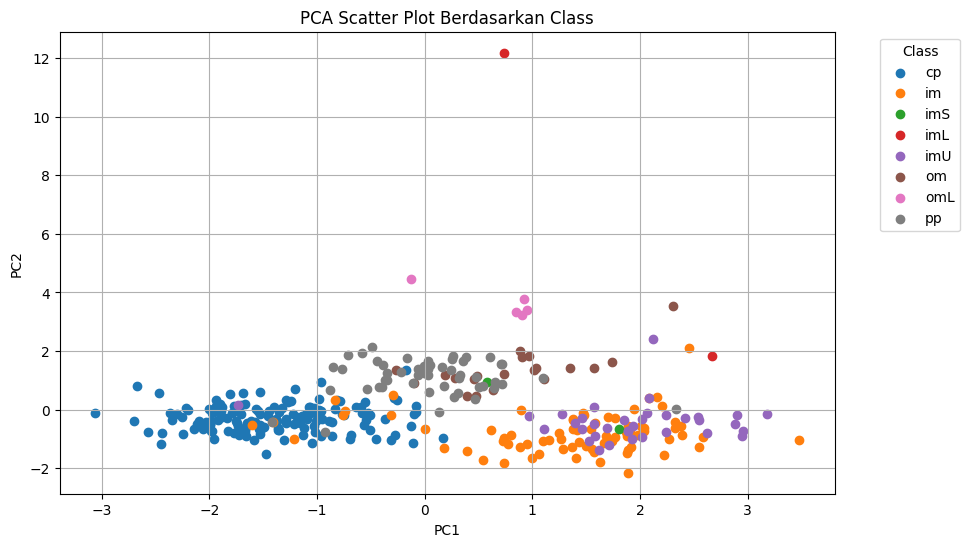

In [2]:

engine = create_engine("mysql+pymysql://root:@localhost/psd")

query = "SELECT mcg, gvh, lip, chg, aac, alm1, alm2, localization_class FROM ecoli"
df = pd.read_sql(query, engine)

X = df.drop(columns=["localization_class"])
y = df["localization_class"]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

data_pca = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
data_pca['localization_class'] = y
data_pca.to_csv('pca_ecoli.csv', index=False)


plt.figure(figsize=(10,6))
for label in data_pca['localization_class'].unique():
    subset = data_pca[data_pca['localization_class'] == label]
    plt.scatter(subset['PC1'], subset['PC2'], label=label)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Scatter Plot Berdasarkan Class")
plt.legend(title="Class", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()


In [3]:
X_resampled, y_resampled = ADASYN(n_neighbors=1, sampling_strategy='minority').fit_resample(X, y)
print(sorted(Counter(y_resampled).items()))

X_resampled, y_resampled = ADASYN(n_neighbors=1, sampling_strategy='minority').fit_resample(X_resampled, y_resampled)
print(sorted(Counter(y_resampled).items()))

X_resampled, y_resampled = ADASYN(n_neighbors=4, sampling_strategy='minority').fit_resample(X_resampled, y_resampled)
print(sorted(Counter(y_resampled).items()))

X_resampled, y_resampled = ADASYN(n_neighbors=19, sampling_strategy='minority').fit_resample(X_resampled, y_resampled)
print(sorted(Counter(y_resampled).items()))

X_resampled, y_resampled = ADASYN(n_neighbors=34, sampling_strategy='minority').fit_resample(X_resampled, y_resampled)
print(sorted(Counter(y_resampled).items()))

X_resampled, y_resampled = ADASYN(n_neighbors=51, sampling_strategy='minority').fit_resample(X_resampled, y_resampled)
print(sorted(Counter(y_resampled).items()))

X_resampled, y_resampled = ADASYN(n_neighbors=76, sampling_strategy='minority').fit_resample(X_resampled, y_resampled)
print(sorted(Counter(y_resampled).items()))

NameError: name 'ADASYN' is not defined